# Event Log Preparation and Process Discovery

This notebook first analyzes Experiment 10, Run 1 from the smart-pallet logistics dataset as a worked example. It then applies the same event-log preparation, descriptive statistics, variant analysis, directly-follows analysis, and bottleneck analysis to all 27 experiments and all 20 runs per experiment so that the configurations can be compared and the research questions can be answered using repeated observations.

## Libraries and Project Paths

This section defines the required libraries and project folders. Raw data is read from `../data/raw`, processed data is saved to `../data/processed`, and generated outputs are written to `../outputs`.


In [1]:
import pandas as pd
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Resolve the project root independently of the folder used to launch Jupyter.
working_directory = Path.cwd().resolve()
project_candidates = [
    working_directory,
    working_directory / "Project",
    working_directory.parent,
    working_directory.parent / "Project",
]

PROJECT_ROOT = next(
    (
        candidate
        for candidate in project_candidates
        if (candidate / "data" / "raw").exists()
        and (candidate / "notebooks").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the Project folder. Open the notebook from the PM Project workspace."
    )

RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"

PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)
(OUTPUTS / "tables").mkdir(parents=True, exist_ok=True)
(OUTPUTS / "figures").mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder exists:", RAW_DATA.exists())
print("Files in raw data folder:")
for file in RAW_DATA.iterdir():
    print("-", file.name)

Project root: C:\Users\rober\Downloads\PM Project\Project
Raw data folder exists: True
Files in raw data folder:
- .DS_Store
- experimentResults.xlsx
- Input.zip
- LogFiles.zip
- LogFilesProductWarmupFilter.zip
- Output.zip
- OutputWarmupFilter.zip
- README.pdf


## ZIP Inspection and Log Selection

The raw product-level event logs are stored in `LogFilesProductWarmupFilter.zip`. `Exp10Run1.txt` is selected as the starting log, using an exact filename match to avoid accidentally selecting `Exp10Run10.txt` or similar files.


In [3]:
zip_path = RAW_DATA / "LogFilesProductWarmupFilter.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Number of files inside ZIP:", len(files))
print("First 20 files:")
for file in files[:20]:
    print(file)

Number of files inside ZIP: 541
First 20 files:
LogFilesProductWarmupFilter/
LogFilesProductWarmupFilter/Exp10Run1.txt
LogFilesProductWarmupFilter/Exp10Run10.txt
LogFilesProductWarmupFilter/Exp10Run11.txt
LogFilesProductWarmupFilter/Exp10Run12.txt
LogFilesProductWarmupFilter/Exp10Run13.txt
LogFilesProductWarmupFilter/Exp10Run14.txt
LogFilesProductWarmupFilter/Exp10Run15.txt
LogFilesProductWarmupFilter/Exp10Run16.txt
LogFilesProductWarmupFilter/Exp10Run17.txt
LogFilesProductWarmupFilter/Exp10Run18.txt
LogFilesProductWarmupFilter/Exp10Run19.txt
LogFilesProductWarmupFilter/Exp10Run2.txt
LogFilesProductWarmupFilter/Exp10Run20.txt
LogFilesProductWarmupFilter/Exp10Run3.txt
LogFilesProductWarmupFilter/Exp10Run4.txt
LogFilesProductWarmupFilter/Exp10Run5.txt
LogFilesProductWarmupFilter/Exp10Run6.txt
LogFilesProductWarmupFilter/Exp10Run7.txt
LogFilesProductWarmupFilter/Exp10Run8.txt


In [4]:
target_files = [f for f in files if "Exp10Run1" in f]

target_files

['LogFilesProductWarmupFilter/Exp10Run1.txt',
 'LogFilesProductWarmupFilter/Exp10Run10.txt',
 'LogFilesProductWarmupFilter/Exp10Run11.txt',
 'LogFilesProductWarmupFilter/Exp10Run12.txt',
 'LogFilesProductWarmupFilter/Exp10Run13.txt',
 'LogFilesProductWarmupFilter/Exp10Run14.txt',
 'LogFilesProductWarmupFilter/Exp10Run15.txt',
 'LogFilesProductWarmupFilter/Exp10Run16.txt',
 'LogFilesProductWarmupFilter/Exp10Run17.txt',
 'LogFilesProductWarmupFilter/Exp10Run18.txt',
 'LogFilesProductWarmupFilter/Exp10Run19.txt']

In [5]:
target_file = target_files[0]

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open(target_file) as f:
        log = pd.read_csv(f, sep=None, engine="python")

print("Shape:", log.shape)
log.head()

Shape: (82507, 11)


,﻿uniqueID,productID,productIDStr,productType,productNr,event,timeStamp,vehicleType,vehicle,currentDecayLevel,processingStation
0,22007,(?),.Models.MUs.product2:363,product2,363,finishedProcessingRegion2,2020/01/01 02:00:00.0858,NaN,NaN,86.363714,product2Process
1,22008,(?),.Models.MUs.product2:363,product2,363,productCallsForTransportRegion3,2020/01/01 02:00:00.0858,NaN,NaN,86.363714,NaN
2,22009,(?),.Models.MUs.product2:363,product2,363,assignedToVehicleRegion3,2020/01/01 02:00:00.0858,UAV,UAV:6,86.363714,NaN
3,22010,(?),.Models.MUs.product1:711,product1,711,arrivalAtSource,2020/01/01 02:00:00.1498,NaN,NaN,100.000000,NaN
4,22011,(?),.Models.MUs.product1:711,product1,711,productCallsForTransportRegion1,2020/01/01 02:00:00.1498,NaN,NaN,100.000000,NaN


In [6]:
log.columns.tolist()

['\ufeffuniqueID',
 'productID',
 'productIDStr',
 'productType',
 'productNr',
 'event',
 'timeStamp',
 'vehicleType',
 'vehicle',
 'currentDecayLevel',
 'processingStation']

In [7]:
target_files = [f for f in files if f.endswith("/Exp10Run1.txt") or f.endswith("Exp10Run1.txt")]

target_files


['LogFilesProductWarmupFilter/Exp10Run1.txt']

In [8]:
target_file = target_files[0]

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open(target_file) as f:
        log = pd.read_csv(f, sep=None, engine="python")

print("Shape:", log.shape)
log.head()

Shape: (82507, 11)


,﻿uniqueID,productID,productIDStr,productType,productNr,event,timeStamp,vehicleType,vehicle,currentDecayLevel,processingStation
0,22007,(?),.Models.MUs.product2:363,product2,363,finishedProcessingRegion2,2020/01/01 02:00:00.0858,NaN,NaN,86.363714,product2Process
1,22008,(?),.Models.MUs.product2:363,product2,363,productCallsForTransportRegion3,2020/01/01 02:00:00.0858,NaN,NaN,86.363714,NaN
2,22009,(?),.Models.MUs.product2:363,product2,363,assignedToVehicleRegion3,2020/01/01 02:00:00.0858,UAV,UAV:6,86.363714,NaN
3,22010,(?),.Models.MUs.product1:711,product1,711,arrivalAtSource,2020/01/01 02:00:00.1498,NaN,NaN,100.000000,NaN
4,22011,(?),.Models.MUs.product1:711,product1,711,productCallsForTransportRegion1,2020/01/01 02:00:00.1498,NaN,NaN,100.000000,NaN


## Event Log Preparation

The raw fields are mapped to process-mining fields: `productIDStr` becomes `case_id`, `event` becomes `activity`, and `timeStamp` becomes `timestamp`. These are the minimum required fields for process mining, while extra attributes such as vehicle type, vehicle, product type, decay level, and processing station are retained for possible later analysis.


In [9]:
event_log = log.rename(columns={
    "productIDStr": "case_id",
    "event": "activity",
    "timeStamp": "timestamp"
})

event_log.head()

,﻿uniqueID,productID,case_id,productType,productNr,activity,timestamp,vehicleType,vehicle,currentDecayLevel,processingStation
0,22007,(?),.Models.MUs.product2:363,product2,363,finishedProcessingRegion2,2020/01/01 02:00:00.0858,NaN,NaN,86.363714,product2Process
1,22008,(?),.Models.MUs.product2:363,product2,363,productCallsForTransportRegion3,2020/01/01 02:00:00.0858,NaN,NaN,86.363714,NaN
2,22009,(?),.Models.MUs.product2:363,product2,363,assignedToVehicleRegion3,2020/01/01 02:00:00.0858,UAV,UAV:6,86.363714,NaN
3,22010,(?),.Models.MUs.product1:711,product1,711,arrivalAtSource,2020/01/01 02:00:00.1498,NaN,NaN,100.000000,NaN
4,22011,(?),.Models.MUs.product1:711,product1,711,productCallsForTransportRegion1,2020/01/01 02:00:00.1498,NaN,NaN,100.000000,NaN


In [10]:
columns_to_keep = [
    "case_id",
    "activity",
    "timestamp",
    "productType",
    "productNr",
    "vehicleType",
    "vehicle",
    "currentDecayLevel",
    "processingStation"
]

event_log = event_log[columns_to_keep]

event_log.head()

,case_id,activity,timestamp,productType,productNr,vehicleType,vehicle,currentDecayLevel,processingStation
0,.Models.MUs.product2:363,finishedProcessingRegion2,2020/01/01 02:00:00.0858,product2,363,NaN,NaN,86.363714,product2Process
1,.Models.MUs.product2:363,productCallsForTransportRegion3,2020/01/01 02:00:00.0858,product2,363,NaN,NaN,86.363714,NaN
2,.Models.MUs.product2:363,assignedToVehicleRegion3,2020/01/01 02:00:00.0858,product2,363,UAV,UAV:6,86.363714,NaN
3,.Models.MUs.product1:711,arrivalAtSource,2020/01/01 02:00:00.1498,product1,711,NaN,NaN,100.000000,NaN
4,.Models.MUs.product1:711,productCallsForTransportRegion1,2020/01/01 02:00:00.1498,product1,711,NaN,NaN,100.000000,NaN


In [11]:
event_log["timestamp"] = pd.to_datetime(event_log["timestamp"], errors="coerce")

event_log = event_log.sort_values(["case_id", "timestamp"])

event_log.head()

,case_id,activity,timestamp,productType,productNr,vehicleType,vehicle,currentDecayLevel,processingStation
7468,.Models.MUs.product1:1000,arrivalAtSource,2020-01-01 02:49:04.958800,product1,1000,NaN,NaN,100.000000,NaN
7469,.Models.MUs.product1:1000,productCallsForTransportRegion1,2020-01-01 02:49:04.958800,product1,1000,NaN,NaN,100.000000,NaN
7470,.Models.MUs.product1:1000,assignedToVehicleRegion1,2020-01-01 02:49:04.958800,product1,1000,AGV,AGV:1,100.000000,NaN
7483,.Models.MUs.product1:1000,pickedUpRegion1,2020-01-01 02:49:07.801600,product1,1000,AGV,AGV:1,98.588698,NaN
7552,.Models.MUs.product1:1000,droppedOffRegion2,2020-01-01 02:49:37.801600,product1,1000,AGV,AGV:1,84.856079,NaN


In [12]:
event_log.isna().sum()

case_id                  0
activity                 0
timestamp                0
productType              0
productNr                0
vehicleType          37498
vehicle              37498
currentDecayLevel        0
processingStation    67505
dtype: int64

In [13]:
event_log = event_log.dropna(subset=["case_id", "activity", "timestamp"])

print("Shape after removing missing required values:", event_log.shape)

Shape after removing missing required values: (82507, 9)


In [14]:
output_path = PROCESSED_DATA / "clean_event_log_exp10_run1.csv"

event_log.to_csv(output_path, index=False)

print("Saved clean event log to:", output_path)

Saved clean event log to: C:\Users\rober\Downloads\PM Project\Project\data\processed\clean_event_log_exp10_run1.csv


## Descriptive Statistics and Variant Analysis

This section calculates the number of cases, events, activities, variants, case durations, activity frequencies, and most frequent variants. Variants are unique sequences of activities followed by cases.


In [15]:
num_cases = event_log["case_id"].nunique()
num_events = len(event_log)
num_activities = event_log["activity"].nunique()

variants = event_log.groupby("case_id")["activity"].apply(tuple)
num_variants = variants.nunique()

case_durations = event_log.groupby("case_id")["timestamp"].agg(["min", "max"])
case_durations["duration"] = case_durations["max"] - case_durations["min"]

avg_duration = case_durations["duration"].mean()
longest_duration = case_durations["duration"].max()

print("Number of cases:", num_cases)
print("Number of events:", num_events)
print("Number of activities:", num_activities)
print("Number of variants:", num_variants)
print("Average case duration:", avg_duration)
print("Longest case duration:", longest_duration)

Number of cases: 7559
Number of events: 82507
Number of activities: 11
Number of variants: 10
Average case duration: 0 days 00:04:29.332117462
Longest case duration: 0 days 00:08:16.844200


In [16]:
activity_counts = event_log["activity"].value_counts()

activity_counts
activity_counts.to_csv(OUTPUTS / "activity_frequencies_exp10_run1.csv")

In [17]:
variant_counts = variants.value_counts()

variant_counts.head(10)

activity
(arrivalAtSource, productCallsForTransportRegion1, assignedToVehicleRegion1, pickedUpRegion1, droppedOffRegion2, startProcessingRegion2, finishedProcessingRegion2, productCallsForTransportRegion3, assignedToVehicleRegion3, pickedUpRegion3, droppedOffRegion3)    7441
(finishedProcessingRegion2, productCallsForTransportRegion3, assignedToVehicleRegion3, pickedUpRegion3, droppedOffRegion3)                                                                                                                                              47
(arrivalAtSource, productCallsForTransportRegion1, assignedToVehicleRegion1, pickedUpRegion1, droppedOffRegion2, startProcessingRegion2)                                                                                                                                45
(pickedUpRegion1, droppedOffRegion2, startProcessingRegion2, finishedProcessingRegion2, productCallsForTransportRegion3, assignedToVehicleRegion3, pickedUpRegion3, droppedOffRegion3)        

In [18]:
variant_counts.head(20).to_csv(OUTPUTS / "top_20_variants_exp10_run1.csv")


In [19]:
######

In [20]:
log_statistics = pd.DataFrame({
    "metric": [
        "number_of_cases",
        "number_of_events",
        "number_of_activities",
        "number_of_variants",
        "average_case_duration",
        "longest_case_duration"
    ],
    "value": [
        num_cases,
        num_events,
        num_activities,
        num_variants,
        str(avg_duration),
        str(longest_duration)
    ]
})

log_statistics.to_csv(OUTPUTS / "tables" / "log_statistics_exp10_run1.csv", index=False)

log_statistics

,metric,value
0,number_of_cases,7559
1,number_of_events,82507
2,number_of_activities,11
3,number_of_variants,10
4,average_case_duration,0 days 00:04:29.332117462
5,longest_case_duration,0 days 00:08:16.844200


In [21]:
case_durations.to_csv(OUTPUTS / "tables" / "case_duration_statistics_exp10_run1.csv")

case_durations.head()

,min,max,duration
case_id,,,
.Models.MUs.product1:1000,2020-01-01 02:49:04.958800,2020-01-01 02:53:23.068300,0 days 00:04:18.109500
.Models.MUs.product1:1001,2020-01-01 02:49:12.357900,2020-01-01 02:52:44.966100,0 days 00:03:32.608200
.Models.MUs.product1:1002,2020-01-01 02:49:22.446600,2020-01-01 02:51:51.119500,0 days 00:02:28.672900
.Models.MUs.product1:1003,2020-01-01 02:49:27.838200,2020-01-01 02:52:19.567900,0 days 00:02:51.729700
.Models.MUs.product1:1004,2020-01-01 02:49:30.367400,2020-01-01 02:53:14.234700,0 days 00:03:43.867300


## Directly-Follows and Bottleneck Analysis

Directly-follows relations summarize which activity is followed by which next activity. Bottleneck analysis calculates the average duration between consecutive activities within each case.


In [22]:
event_log_sorted = event_log.sort_values(["case_id", "timestamp"])

event_log_sorted["next_activity"] = event_log_sorted.groupby("case_id")["activity"].shift(-1)

dfg = (
    event_log_sorted
    .dropna(subset=["next_activity"])
    .groupby(["activity", "next_activity"])
    .size()
    .reset_index(name="frequency")
    .sort_values("frequency", ascending=False)
)

dfg.to_csv(OUTPUTS / "tables" / "directly_follows_graph_exp10_run1.csv", index=False)

dfg.head(20)

,activity,next_activity,frequency
4,finishedProcessingRegion2,productCallsForTransportRegion3,7502
8,productCallsForTransportRegion3,assignedToVehicleRegion3,7502
2,assignedToVehicleRegion3,pickedUpRegion3,7501
3,droppedOffRegion2,startProcessingRegion2,7500
5,pickedUpRegion1,droppedOffRegion2,7499
6,pickedUpRegion3,droppedOffRegion3,7498
0,arrivalAtSource,productCallsForTransportRegion1,7497
1,assignedToVehicleRegion1,pickedUpRegion1,7497
7,productCallsForTransportRegion1,assignedToVehicleRegion1,7497
9,startProcessingRegion2,finishedProcessingRegion2,7455


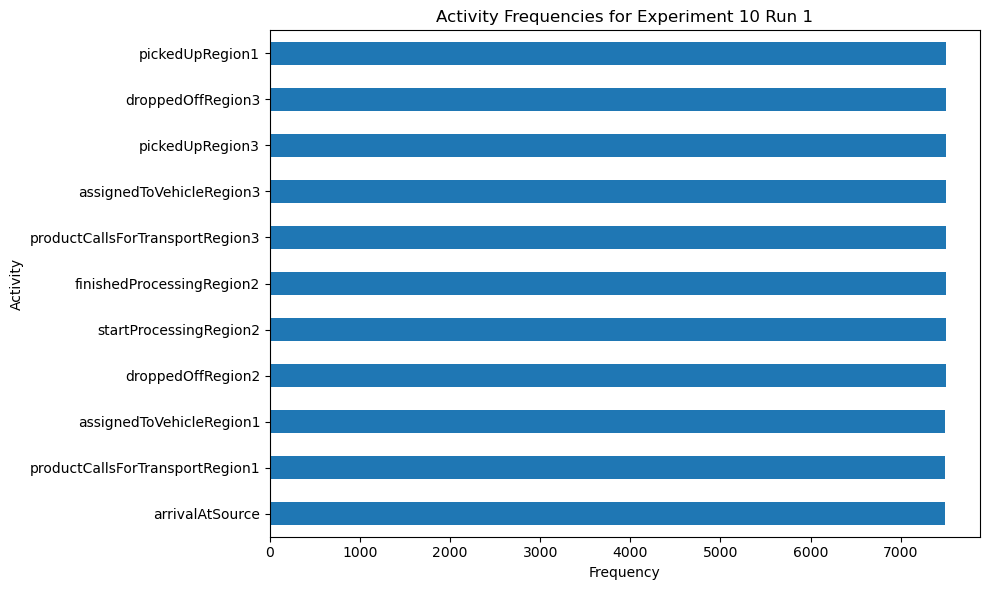

In [23]:
(OUTPUTS / "figures").mkdir(parents=True, exist_ok=True)

activity_counts.sort_values().plot(kind="barh", figsize=(10, 6))

plt.xlabel("Frequency")
plt.ylabel("Activity")
plt.title("Activity Frequencies for Experiment 10 Run 1")
plt.tight_layout()

plt.savefig(OUTPUTS / "figures" / "activity_frequencies_exp10_run1.png", dpi=300)
plt.show()

In [24]:
event_log_sorted["next_timestamp"] = event_log_sorted.groupby("case_id")["timestamp"].shift(-1)

event_log_sorted["transition_duration"] = (
    event_log_sorted["next_timestamp"] - event_log_sorted["timestamp"]
)

bottlenecks = (
    event_log_sorted
    .dropna(subset=["next_activity", "transition_duration"])
    .groupby(["activity", "next_activity"])["transition_duration"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

bottlenecks.to_csv(OUTPUTS / "tables" / "bottleneck_transitions_exp10_run1.csv", index=False)

bottlenecks.head(10)

,activity,next_activity,count,mean,median,max
9,startProcessingRegion2,finishedProcessingRegion2,7455,0 days 00:03:43.186801341,0 days 00:03:43.082000,0 days 00:06:42.055100
6,pickedUpRegion3,droppedOffRegion3,7498,0 days 00:00:19.385391811,0 days 00:00:20,0 days 00:00:37.500000
5,pickedUpRegion1,droppedOffRegion2,7499,0 days 00:00:14.546272836,0 days 00:00:15,0 days 00:00:30
2,assignedToVehicleRegion3,pickedUpRegion3,7501,0 days 00:00:09.172308598,0 days 00:00:04.746900,0 days 00:00:37.500000
1,assignedToVehicleRegion1,pickedUpRegion1,7497,0 days 00:00:05.383265772,0 days 00:00:00.625400,0 days 00:00:30
8,productCallsForTransportRegion3,assignedToVehicleRegion3,7502,0 days 00:00:00.857947613,0 days 00:00:00,0 days 00:01:00.190200
7,productCallsForTransportRegion1,assignedToVehicleRegion1,7497,0 days 00:00:00.265913138,0 days 00:00:00,0 days 00:00:44.034900
0,arrivalAtSource,productCallsForTransportRegion1,7497,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00
3,droppedOffRegion2,startProcessingRegion2,7500,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00
4,finishedProcessingRegion2,productCallsForTransportRegion3,7502,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


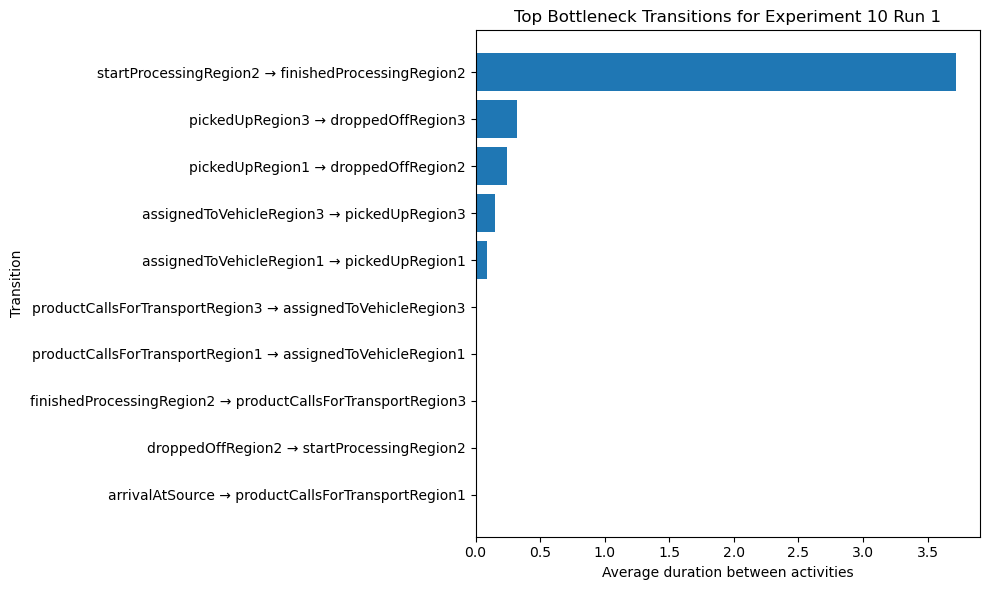

In [25]:
top_bottlenecks = bottlenecks.head(10).copy()

top_bottlenecks["transition"] = (
    top_bottlenecks["activity"] + " → " + top_bottlenecks["next_activity"]
)

top_bottlenecks = top_bottlenecks.sort_values("mean")

plt.figure(figsize=(10, 6))
plt.barh(top_bottlenecks["transition"], top_bottlenecks["mean"].dt.total_seconds() / 60)

plt.xlabel("Average duration between activities")
plt.ylabel("Transition")
plt.title("Top Bottleneck Transitions for Experiment 10 Run 1")
plt.tight_layout()

plt.savefig(OUTPUTS / "figures" / "top_bottleneck_transitions_exp10_run1.png", dpi=300)
plt.show()

## Summary of the Single-Experiment Worked Example

The cells above generate a cleaned event log, log statistics table, case duration table, directly-follows table, bottleneck table, activity frequency figure, and bottleneck transition figure for Experiment 10, Run 1. The following section repeats the same analytical workflow for every experiment, aggregates the 20 runs belonging to each configuration, compares the results, and answers the research questions.

# Multi-Experiment Analysis and Comparison

The worked example above demonstrates the complete analysis for one log. This section generalizes the same procedure to all warm-up-filtered product logs. One **case** is one product journey, one **run** is one simulation replication, and one **experiment** is a fleet and dispatch-rule configuration. Each experiment contains 20 runs, so the comparison below is based on all 540 logs rather than one selected run.

To keep the repository manageable, the notebook saves a cleaned Run 1 log for each experiment as a reproducible example, while all 20 runs are still processed in memory and included in the statistics, variants, directly-follows relations, bottlenecks, and comparison figures.

In [26]:
import re
from collections import Counter, defaultdict

MULTI_OUTPUTS = OUTPUTS / "notebook_multi_experiment"
MULTI_TABLES = MULTI_OUTPUTS / "tables"
MULTI_FIGURES = MULTI_OUTPUTS / "figures"
MULTI_PROCESSED = PROCESSED_DATA / "multi_experiment_examples"

for folder in [MULTI_OUTPUTS, MULTI_TABLES, MULTI_FIGURES, MULTI_PROCESSED]:
    folder.mkdir(parents=True, exist_ok=True)

log_pattern = re.compile(r"Exp(\d+)Run(\d+)\.txt$")
log_members = []
for member in files:
    match = log_pattern.search(member)
    if match:
        log_members.append({
            "experiment": int(match.group(1)),
            "run": int(match.group(2)),
            "member": member,
        })

log_members = pd.DataFrame(log_members).sort_values(["experiment", "run"])
print(f"Discovered {len(log_members)} logs across {log_members['experiment'].nunique()} experiments.")
log_members.groupby("experiment")["run"].nunique().head()

Discovered 540 logs across 27 experiments.


experiment
1    20
2    20
3    20
4    20
5    20
Name: run, dtype: int64

## Reusable Preparation and Evaluation Functions

The functions below use the same column mapping and calculations as the Experiment 10, Run 1 example, although they aggregate the results at experiment level and retain the run number so repeated simulation runs are never mixed into a single case.

In [27]:
def prepare_product_log(zip_file, member_name):
    with zip_file.open(member_name) as source:
        raw_log = pd.read_csv(
            source,
            sep="\t",
            encoding="utf-8-sig",
            na_values=["NA", ""],
            keep_default_na=True,
        )

    prepared = raw_log.rename(columns={
        "productIDStr": "case_id",
        "event": "activity",
        "timeStamp": "timestamp",
    })
    prepared = prepared[columns_to_keep].copy()
    prepared["timestamp"] = pd.to_datetime(prepared["timestamp"], errors="coerce")
    prepared = prepared.dropna(subset=["case_id", "activity", "timestamp"])
    # Stable sorting preserves the source-log order when multiple events share a timestamp.
    return prepared.sort_values(["case_id", "timestamp"], kind="stable")


def evaluate_experiment(zip_file, experiment_files):
    experiment = int(experiment_files["experiment"].iloc[0])
    run_statistics = []
    case_duration_frames = []
    activity_counter = Counter()
    variant_counter = Counter()
    dfg_counter = Counter()
    bottleneck_accumulator = defaultdict(lambda: {"count": 0, "sum_seconds": 0.0, "max_seconds": 0.0})
    final_quality_values = []

    for item in experiment_files.itertuples(index=False):
        prepared = prepare_product_log(zip_file, item.member)

        if item.run == 1:
            prepared.to_csv(
                MULTI_PROCESSED / f"clean_event_log_exp{experiment}_run1.csv",
                index=False,
            )

        sequences = prepared.groupby("case_id", sort=False)["activity"].apply(tuple)
        variant_counter.update(sequences)
        activity_counter.update(prepared["activity"])

        case_times = prepared.groupby("case_id")["timestamp"].agg(["min", "max"])
        case_times["duration_seconds"] = (case_times["max"] - case_times["min"]).dt.total_seconds()
        case_times = case_times.reset_index()
        case_times.insert(0, "run", int(item.run))
        case_times.insert(0, "experiment", experiment)
        case_duration_frames.append(case_times)

        final_quality = prepared.groupby("case_id", sort=False)["currentDecayLevel"].last().dropna()
        final_quality_values.extend(final_quality.tolist())

        transitions = prepared[["case_id", "activity", "timestamp"]].copy()
        transitions["next_activity"] = transitions.groupby("case_id")["activity"].shift(-1)
        transitions["next_timestamp"] = transitions.groupby("case_id")["timestamp"].shift(-1)
        transitions["duration_seconds"] = (
            transitions["next_timestamp"] - transitions["timestamp"]
        ).dt.total_seconds()
        transitions = transitions.dropna(subset=["next_activity", "duration_seconds"])

        dfg_counts = transitions.groupby(["activity", "next_activity"]).size()
        dfg_counter.update(dfg_counts.to_dict())

        transition_stats = transitions.groupby(["activity", "next_activity"])["duration_seconds"].agg(
            count="count", total="sum", maximum="max"
        )
        for transition, row in transition_stats.iterrows():
            values = bottleneck_accumulator[transition]
            values["count"] += int(row["count"])
            values["sum_seconds"] += float(row["total"])
            values["max_seconds"] = max(values["max_seconds"], float(row["maximum"]))

        run_statistics.append({
            "experiment": experiment,
            "run": int(item.run),
            "number_of_cases": prepared["case_id"].nunique(),
            "number_of_events": len(prepared),
            "number_of_activities": prepared["activity"].nunique(),
            "number_of_variants": sequences.nunique(),
            "average_case_duration_min": case_times["duration_seconds"].mean() / 60,
            "longest_case_duration_min": case_times["duration_seconds"].max() / 60,
            "average_final_quality": final_quality.mean(),
        })

    case_durations = pd.concat(case_duration_frames, ignore_index=True)
    run_statistics = pd.DataFrame(run_statistics)

    activity_frequencies = pd.DataFrame(
        activity_counter.most_common(), columns=["activity", "frequency"]
    )
    variants = pd.DataFrame(
        [(" -> ".join(sequence), count) for sequence, count in variant_counter.most_common()],
        columns=["variant", "frequency"],
    )
    directly_follows = pd.DataFrame(
        [(a, b, count) for (a, b), count in dfg_counter.most_common()],
        columns=["activity", "next_activity", "frequency"],
    )
    bottlenecks = pd.DataFrame([
        {
            "activity": activity,
            "next_activity": next_activity,
            "frequency": values["count"],
            "mean_duration_min": values["sum_seconds"] / values["count"] / 60,
            "max_duration_min": values["max_seconds"] / 60,
        }
        for (activity, next_activity), values in bottleneck_accumulator.items()
    ]).sort_values("mean_duration_min", ascending=False)

    log_statistics = pd.DataFrame([{
        "experiment": experiment,
        "runs": run_statistics["run"].nunique(),
        "number_of_cases": int(run_statistics["number_of_cases"].sum()),
        "average_cases_per_run": run_statistics["number_of_cases"].mean(),
        "number_of_events": int(run_statistics["number_of_events"].sum()),
        "average_events_per_run": run_statistics["number_of_events"].mean(),
        "number_of_activities": len(activity_counter),
        "number_of_variants": len(variant_counter),
        "average_case_duration_min": case_durations["duration_seconds"].mean() / 60,
        "longest_case_duration_min": case_durations["duration_seconds"].max() / 60,
        "average_final_quality": pd.Series(final_quality_values).mean(),
        "minimum_final_quality": pd.Series(final_quality_values).min(),
    }])

    return {
        "statistics": log_statistics,
        "run_statistics": run_statistics,
        "case_durations": case_durations,
        "activities": activity_frequencies,
        "variants": variants,
        "dfg": directly_follows,
        "bottlenecks": bottlenecks,
    }

## Run the Analysis for All Experiments

For each experiment, the following cell saves the same main tables and figures that were produced for Experiment 10, Run 1. The experiment-level tables combine all 20 runs, while `run_level_log_statistics.csv` preserves the separate repeated-run results used in the comparison.

In [28]:
# Recreate output folders in case this cell is run independently.
for folder in [MULTI_OUTPUTS, MULTI_TABLES, MULTI_FIGURES, MULTI_PROCESSED]:
    folder.mkdir(parents=True, exist_ok=True)

experiment_statistics = []
all_run_statistics = []
all_top_variants = []
all_directly_follows = []
all_bottlenecks = []

with zipfile.ZipFile(zip_path, "r") as product_logs_zip:
    for experiment, experiment_files in log_members.groupby("experiment", sort=True):
        results = evaluate_experiment(product_logs_zip, experiment_files)

        results["statistics"].to_csv(
            MULTI_TABLES / f"log_statistics_exp{experiment}.csv", index=False
        )
        results["case_durations"].to_csv(
            MULTI_TABLES / f"case_duration_statistics_exp{experiment}.csv", index=False
        )
        results["activities"].to_csv(
            MULTI_TABLES / f"activity_frequencies_exp{experiment}.csv", index=False
        )
        results["variants"].head(20).to_csv(
            MULTI_TABLES / f"top_20_variants_exp{experiment}.csv", index=False
        )
        results["dfg"].to_csv(
            MULTI_TABLES / f"directly_follows_graph_exp{experiment}.csv", index=False
        )
        results["bottlenecks"].to_csv(
            MULTI_TABLES / f"bottleneck_transitions_exp{experiment}.csv", index=False
        )

        activity_plot = results["activities"].sort_values("frequency")
        plt.figure(figsize=(10, 6))
        plt.barh(activity_plot["activity"], activity_plot["frequency"])
        plt.xlabel("Frequency across 20 runs")
        plt.ylabel("Activity")
        plt.title(f"Activity Frequencies for Experiment {experiment}")
        plt.tight_layout()
        plt.savefig(MULTI_FIGURES / f"activity_frequencies_exp{experiment}.png", dpi=200)
        plt.close()

        bottleneck_plot = results["bottlenecks"].head(10).copy()
        bottleneck_plot["transition"] = (
            bottleneck_plot["activity"] + " -> " + bottleneck_plot["next_activity"]
        )
        bottleneck_plot = bottleneck_plot.sort_values("mean_duration_min")
        plt.figure(figsize=(10, 6))
        plt.barh(bottleneck_plot["transition"], bottleneck_plot["mean_duration_min"])
        plt.xlabel("Average duration between activities (minutes)")
        plt.ylabel("Transition")
        plt.title(f"Top Bottleneck Transitions for Experiment {experiment}")
        plt.tight_layout()
        plt.savefig(MULTI_FIGURES / f"top_bottleneck_transitions_exp{experiment}.png", dpi=200)
        plt.close()

        experiment_statistics.append(results["statistics"])
        all_run_statistics.append(results["run_statistics"])

        top_variants = results["variants"].head(20).copy()
        top_variants.insert(0, "experiment", experiment)
        all_top_variants.append(top_variants)

        dfg_table = results["dfg"].copy()
        dfg_table.insert(0, "experiment", experiment)
        all_directly_follows.append(dfg_table)

        bottleneck_table = results["bottlenecks"].copy()
        bottleneck_table.insert(0, "experiment", experiment)
        all_bottlenecks.append(bottleneck_table)

        print(f"Experiment {experiment:>2}: processed {len(experiment_files)} runs")

experiment_statistics = pd.concat(experiment_statistics, ignore_index=True)
run_level_statistics = pd.concat(all_run_statistics, ignore_index=True)
top_variants_all_experiments = pd.concat(all_top_variants, ignore_index=True)
directly_follows_all_experiments = pd.concat(all_directly_follows, ignore_index=True)
bottlenecks_all_experiments = pd.concat(all_bottlenecks, ignore_index=True)

experiment_statistics.to_csv(MULTI_TABLES / "experiment_log_statistics_comparison.csv", index=False)
run_level_statistics.to_csv(MULTI_TABLES / "run_level_log_statistics.csv", index=False)
top_variants_all_experiments.to_csv(MULTI_TABLES / "top_20_variants_all_experiments.csv", index=False)
directly_follows_all_experiments.to_csv(MULTI_TABLES / "directly_follows_all_experiments.csv", index=False)
bottlenecks_all_experiments.to_csv(MULTI_TABLES / "bottlenecks_all_experiments.csv", index=False)

experiment_statistics

Experiment  1: processed 20 runs
Experiment  2: processed 20 runs
Experiment  3: processed 20 runs
Experiment  4: processed 20 runs
Experiment  5: processed 20 runs
Experiment  6: processed 20 runs
Experiment  7: processed 20 runs
Experiment  8: processed 20 runs
Experiment  9: processed 20 runs
Experiment 10: processed 20 runs
Experiment 11: processed 20 runs
Experiment 12: processed 20 runs
Experiment 13: processed 20 runs
Experiment 14: processed 20 runs
Experiment 15: processed 20 runs
Experiment 16: processed 20 runs
Experiment 17: processed 20 runs
Experiment 18: processed 20 runs
Experiment 19: processed 20 runs
Experiment 20: processed 20 runs
Experiment 21: processed 20 runs
Experiment 22: processed 20 runs
Experiment 23: processed 20 runs
Experiment 24: processed 20 runs
Experiment 25: processed 20 runs
Experiment 26: processed 20 runs
Experiment 27: processed 20 runs


,experiment,runs,number_of_cases,average_cases_per_run,number_of_events,average_events_per_run,number_of_activities,number_of_variants,average_case_duration_min,longest_case_duration_min,average_final_quality,minimum_final_quality
0,1,20,152766,7638.30,1666342,83317.10,11,15,4.555994,22.355630,86.505347,2.475988e+01
1,2,20,152747,7637.35,1666310,83315.50,12,16,4.498529,23.545145,88.036013,1.476532e+01
2,3,20,152726,7636.30,1666314,83315.70,11,15,4.419349,19.519473,88.556291,2.470544e+01
3,4,20,153730,7686.50,1650906,82545.30,12,16,14.111400,184.233540,75.728891,1.729975e-03
4,5,20,153181,7659.05,1660759,83037.95,12,16,8.674114,105.134913,78.205261,1.857014e-01
5,6,20,152796,7639.80,1648588,82429.40,12,20,4.586650,102.829108,87.926401,1.520409e-01
6,7,20,152876,7643.80,1660466,83023.30,12,19,4.870321,336.916235,87.489754,0.000000e+00
7,8,20,153147,7657.35,1661290,83064.50,12,16,8.351278,86.221745,76.808433,6.068663e-01
8,9,20,152926,7646.30,1659510,82975.50,12,18,5.035727,328.542833,85.427008,0.000000e+00
9,10,20,152752,7637.60,1666336,83316.80,11,13,4.475324,8.936545,86.310713,5.171052e+01


## Join the Process-Mining Results with the Experiment Configurations

The experiment settings describe the fleet composition and the vehicle and product dispatch rules, while `experimentResults.xlsx` contains the simulation-level quality, time-in-system, and disposal indicators. Joining these sources makes it possible to explain why the discovered process behavior differs between experiments.

In [29]:
with zipfile.ZipFile(RAW_DATA / "Input.zip", "r") as input_zip:
    with input_zip.open("Input/expSettings.txt") as source:
        experiment_settings = pd.read_csv(source, sep="\t", encoding="utf-8-sig")

experiment_settings = experiment_settings.rename(columns={"expNr": "experiment"})
experiment_settings["fleet"] = (
    experiment_settings["description"].str.extract(r"\{([^{}]+)\}")[0].str.replace("UAVV", "UAV")
)
experiment_settings["vehicle_rule"] = experiment_settings["description"].str.extract(r"V:([^;{}]+)")
experiment_settings["product_rule"] = experiment_settings["description"].str.extract(r"P:([^{}]+)\}")

try:
    simulation_results = pd.read_excel(RAW_DATA / "experimentResults.xlsx")
except ImportError:
    # Lightweight fallback for environments where pandas is available but openpyxl is not.
    import xml.etree.ElementTree as ET

    xlsx_path = RAW_DATA / "experimentResults.xlsx"
    spreadsheet_ns = {"x": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    with zipfile.ZipFile(xlsx_path, "r") as workbook_zip:
        shared_strings = []
        if "xl/sharedStrings.xml" in workbook_zip.namelist():
            shared_root = ET.fromstring(workbook_zip.read("xl/sharedStrings.xml"))
            shared_strings = [
                "".join(node.itertext())
                for node in shared_root.findall("x:si", spreadsheet_ns)
            ]

        sheet_root = ET.fromstring(workbook_zip.read("xl/worksheets/sheet1.xml"))
        rows = []
        for row_node in sheet_root.findall(".//x:sheetData/x:row", spreadsheet_ns):
            values = []
            for cell_node in row_node.findall("x:c", spreadsheet_ns):
                value_node = cell_node.find("x:v", spreadsheet_ns)
                value = "" if value_node is None else value_node.text
                if cell_node.get("t") == "s" and value != "":
                    value = shared_strings[int(value)]
                values.append(value)
            rows.append(values)

    simulation_results = pd.DataFrame(rows[1:], columns=rows[0])
    for column in simulation_results.columns:
        converted = pd.to_numeric(simulation_results[column], errors="coerce")
        if converted.notna().all():
            simulation_results[column] = converted

comparison = (
    experiment_statistics
    .merge(
        experiment_settings[["experiment", "fleet", "vehicle_rule", "product_rule", "description"]],
        on="experiment",
        how="left",
    )
    .merge(simulation_results, on="experiment", how="left")
)

comparison.to_csv(MULTI_TABLES / "complete_experiment_comparison.csv", index=False)
comparison[[
    "experiment", "fleet", "vehicle_rule", "product_rule",
    "average_case_duration_min", "average_final_quality",
    "avgTimeInSystem", "avgProductsDisposedPerHour",
]].round(3)

,experiment,fleet,vehicle_rule,product_rule,average_case_duration_min,average_final_quality,avgTimeInSystem,avgProductsDisposedPerHour
0,1,3UAV;1HDF;1AGV,Rnd,Rnd,4.556,86.505,277.448,0.000
1,2,3UAV;1HDF;1AGV,Rnd,lowestUtilization,4.499,88.036,273.987,0.025
2,3,3UAV;1HDF;1AGV,Rnd,shortestTravelDistance,4.419,88.556,269.171,0.000
3,4,3UAV;1HDF;1AGV,lowestQualityDecayValue,lowestUtilization,14.111,75.729,923.903,0.044
4,5,3UAV;1HDF;1AGV,lowestQualityDecayValue,shortestTravelDistance,8.674,78.205,550.060,0.050
5,6,3UAV;1HDF;1AGV,highestQualityDecayValue,lowestUtilization,4.587,87.926,272.092,2.719
6,7,3UAV;1HDF;1AGV,highestQualityDecayValue,shortestTravelDistance,4.870,87.490,296.641,1.412
7,8,3UAV;1HDF;1AGV,lowestQualityDecayValue,random,8.351,76.808,527.538,0.019
8,9,3UAV;1HDF;1AGV,highestQualityDecayValue,random,5.036,85.427,306.582,1.700
9,10,3UAV;2HDF;2AGV,Rnd,Rnd,4.475,86.311,272.372,0.000


## Cross-Experiment Comparison Figures

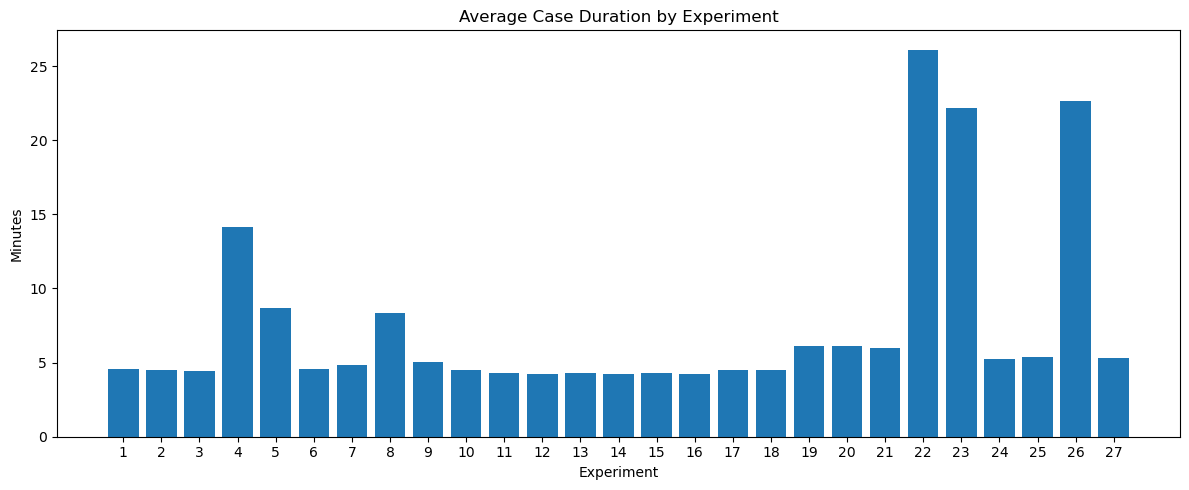

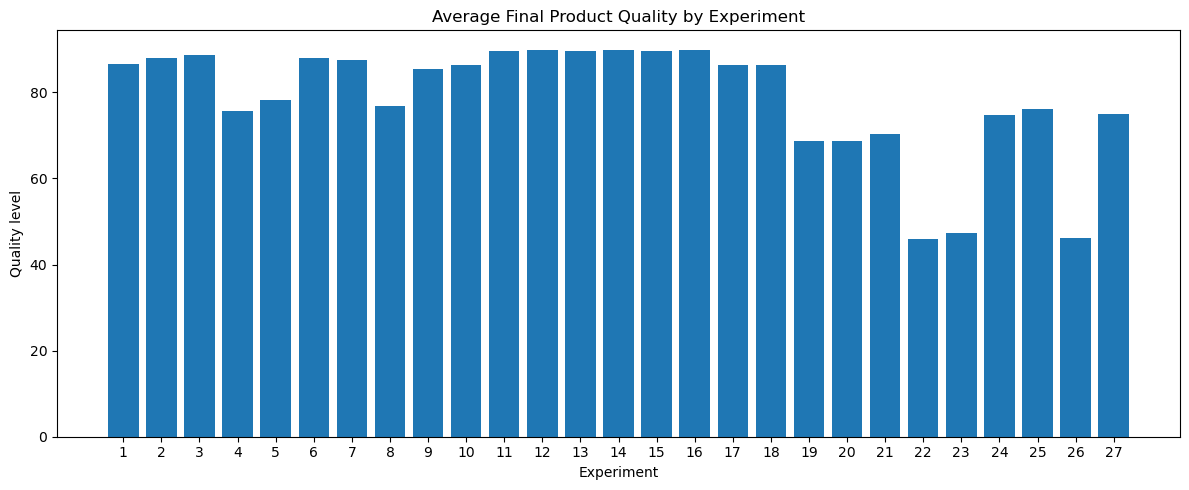

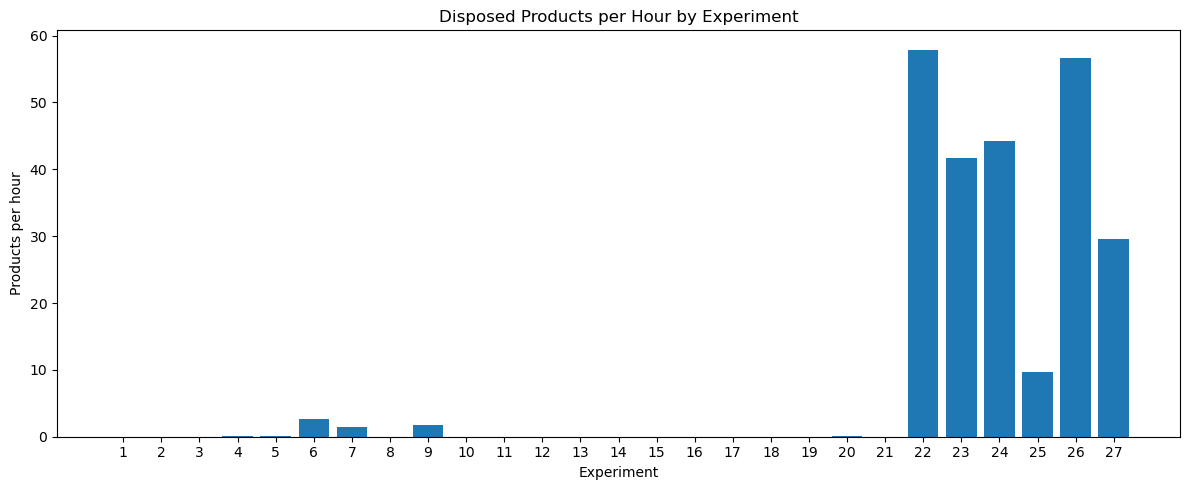

In [30]:
comparison_plot_specs = [
    ("average_case_duration_min", "Average Case Duration by Experiment", "Minutes", "comparison_case_duration.png"),
    ("average_final_quality", "Average Final Product Quality by Experiment", "Quality level", "comparison_final_quality.png"),
    ("avgProductsDisposedPerHour", "Disposed Products per Hour by Experiment", "Products per hour", "comparison_disposal_rate.png"),
]

for column, title, ylabel, filename in comparison_plot_specs:
    plt.figure(figsize=(12, 5))
    plt.bar(comparison["experiment"].astype(str), comparison[column])
    plt.xlabel("Experiment")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(MULTI_FIGURES / filename, dpi=250)
    plt.show()

## Comparison of the Largest Bottlenecks

The next table retains the five slowest transitions for each experiment, while the figure highlights the most severe mean transition delays found anywhere in the dataset.

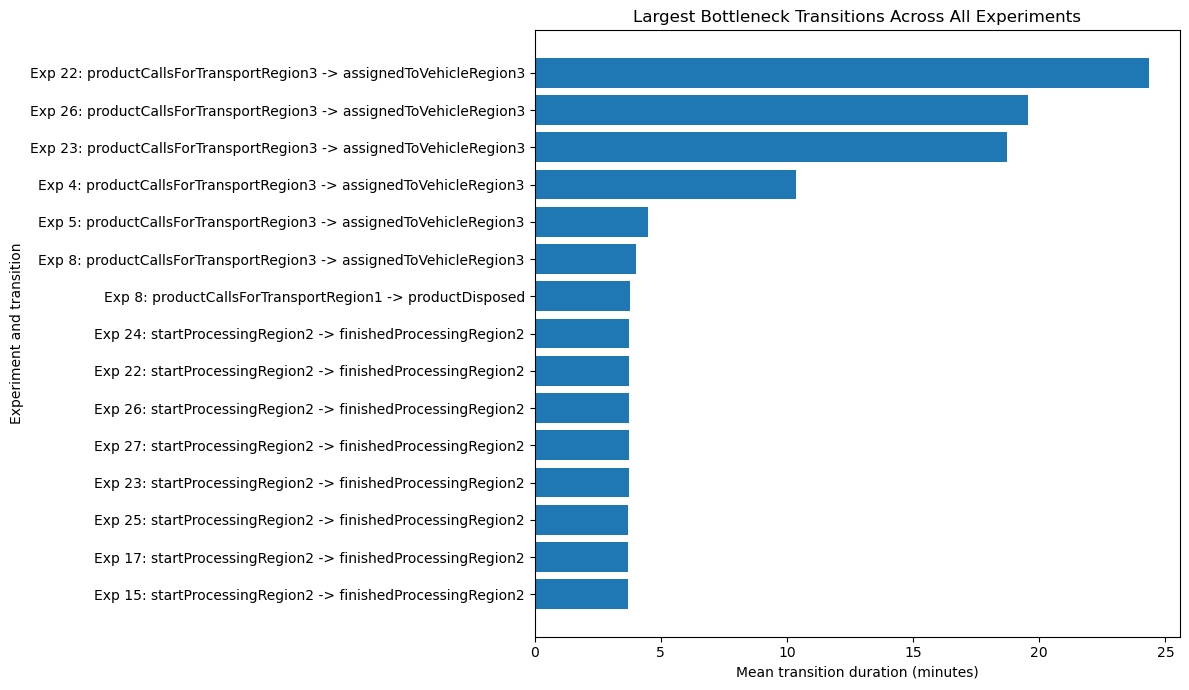

,experiment,activity,next_activity,frequency,mean_duration_min,max_duration_min
0,1,startProcessingRegion2,finishedProcessingRegion2,150452,3.715350,7.544102
1,1,pickedUpRegion3,droppedOffRegion3,151410,0.279572,0.625000
2,1,pickedUpRegion1,droppedOffRegion2,151434,0.203093,0.500000
3,1,assignedToVehicleRegion3,pickedUpRegion3,151435,0.183906,0.625000
4,1,productCallsForTransportRegion3,assignedToVehicleRegion3,151437,0.114635,16.643703
10,2,startProcessingRegion2,finishedProcessingRegion2,150446,3.715276,7.544102
11,2,productCallsForTransportRegion1,productDisposed,4,2.837920,2.837920
12,2,pickedUpRegion3,droppedOffRegion3,151400,0.255891,0.625000
13,2,assignedToVehicleRegion3,pickedUpRegion3,151428,0.179210,0.625000
14,2,pickedUpRegion1,droppedOffRegion2,151446,0.161045,0.500000


In [31]:
top_5_bottlenecks_per_experiment = (
    bottlenecks_all_experiments
    .sort_values(["experiment", "mean_duration_min"], ascending=[True, False])
    .groupby("experiment", as_index=False)
    .head(5)
)
top_5_bottlenecks_per_experiment.to_csv(
    MULTI_TABLES / "top_5_bottlenecks_per_experiment.csv", index=False
)

largest_bottlenecks = (
    bottlenecks_all_experiments
    .sort_values("mean_duration_min", ascending=False)
    .head(15)
    .copy()
)
largest_bottlenecks["label"] = (
    "Exp " + largest_bottlenecks["experiment"].astype(str) + ": "
    + largest_bottlenecks["activity"] + " -> "
    + largest_bottlenecks["next_activity"]
)

largest_bottlenecks = largest_bottlenecks.sort_values("mean_duration_min")
plt.figure(figsize=(12, 7))
plt.barh(largest_bottlenecks["label"], largest_bottlenecks["mean_duration_min"])
plt.xlabel("Mean transition duration (minutes)")
plt.ylabel("Experiment and transition")
plt.title("Largest Bottleneck Transitions Across All Experiments")
plt.tight_layout()
plt.savefig(MULTI_FIGURES / "largest_bottlenecks_all_experiments.png", dpi=250)
plt.show()

top_5_bottlenecks_per_experiment.head(15)

## Answers to the Research Questions

In [32]:
best_quality = comparison.nsmallest(3, "average_case_duration_min").sort_values(
    "average_final_quality", ascending=False
)
best_overall = comparison.sort_values(
    ["average_final_quality", "average_case_duration_min"],
    ascending=[False, True],
).head(3)
worst_disposal = comparison.nlargest(3, "avgProductsDisposedPerHour")
main_bottleneck = bottlenecks_all_experiments.nlargest(1, "mean_duration_min").iloc[0]
dominant_variant_exp10 = (
    top_variants_all_experiments[top_variants_all_experiments["experiment"] == 10]
    .sort_values("frequency", ascending=False)
    .iloc[0]
)

best_lines = "; ".join(
    f"Experiment {int(row.experiment)} ({row.fleet}, {row.product_rule})"
    for row in best_overall.itertuples()
)
worst_lines = "; ".join(
    f"Experiment {int(row.experiment)} ({row.avgProductsDisposedPerHour:.2f} disposed products per hour)"
    for row in worst_disposal.itertuples()
)

answers = f'''
### RQ1: What is the dominant product flow and how stable is it across experiments?

The dominant complete flow in the Experiment 10 baseline is `{dominant_variant_exp10['variant']}`. The same core sequence is visible throughout the directly-follows tables, although incomplete and disposal variants become more frequent in weaker configurations. This means that the control-flow structure is generally stable, while the frequency of exceptional outcomes changes with the fleet and dispatch rules.

### RQ2: Which process variants and configurations perform best?

The strongest overall configurations are {best_lines}. They combine the richer fleet with shortest-travel-distance product dispatch, and they achieve both high final product quality and short case durations. In contrast, the weakest disposal outcomes occur in {worst_lines}, which shows that removing UAV capacity makes the system more vulnerable to congestion and quality loss.

### RQ3: Which transitions indicate the most important bottlenecks?

The largest observed mean delay is `{main_bottleneck['activity']} -> {main_bottleneck['next_activity']}` in Experiment {int(main_bottleneck['experiment'])}, where the mean transition duration is {main_bottleneck['mean_duration_min']:.2f} minutes. Across the comparison, the repeated Region 3 transition from a transport request to vehicle assignment is the clearest operational bottleneck, particularly in Experiments 22, 26, and 23, and this delay is consistent with their lower quality and higher disposal rates.

### Overall conclusion

The multi-experiment analysis shows that the richer `3UAV;2HDF;2AGV` fleet and shortest-travel-distance product dispatch are the most promising choices, whereas the no-UAV fleet produces the most fragile results. Therefore, the main improvement recommendation is to retain UAV capacity, avoid random dispatch as the default decision rule, and monitor Region 3 vehicle-assignment waiting time as a process-level performance indicator.
'''

answers

'\n### RQ1: What is the dominant product flow and how stable is it across experiments?\n\nThe dominant complete flow in the Experiment 10 baseline is `arrivalAtSource -> productCallsForTransportRegion1 -> assignedToVehicleRegion1 -> pickedUpRegion1 -> droppedOffRegion2 -> startProcessingRegion2 -> finishedProcessingRegion2 -> productCallsForTransportRegion3 -> assignedToVehicleRegion3 -> pickedUpRegion3 -> droppedOffRegion3`. The same core sequence is visible throughout the directly-follows tables, although incomplete and disposal variants become more frequent in weaker configurations. This means that the control-flow structure is generally stable, while the frequency of exceptional outcomes changes with the fleet and dispatch rules.\n\n### RQ2: Which process variants and configurations perform best?\n\nThe strongest overall configurations are Experiment 12 (3UAV;2HDF;2AGV, shortestTravelDistance); Experiment 16 (3UAV;2HDF;2AGV, shortestTravelDistance); Experiment 14 (3UAV;2HDF;2AGV, s

## Summary of Generated Multi-Experiment Outputs

The notebook now produces cleaned Run 1 example logs for all 27 experiments, experiment-level and run-level statistics, case-duration tables, activity-frequency tables, top-variant tables, directly-follows tables, bottleneck tables, 54 per-experiment figures, cross-experiment comparison figures, and written answers to the research questions. All results are stored under `../outputs/notebook_multi_experiment`, while the cleaned examples are stored under `../data/processed/multi_experiment_examples`.